### Project :: Evolution Strategies

![img](https://t4.ftcdn.net/jpg/00/17/46/81/240_F_17468143_wY3hsHyfNYoMdG9BlC56HI4JA7pNu63h.jpg)

Remember the idea behind Evolution Strategies? Here's a neat [blog post](https://openai.com/research/evolution-strategies) about 'em.

Can you reproduce their success? You will have to implement evolutionary strategies and see how they work.

This project is optional; has several milestones each worth a number of points [and swag].

__Milestones:__
* [10pts] Basic prototype of evolutionary strategies that works in one thread on CartPole
* [+5pts] Modify the code to make them work in parallel
* [+5pts] if you can run ES distributedly on at least two PCs
* [+10pts] Apply ES to play Atari Pong at least better than random
* [++] Additional points for all kinds of cool stuff besides milestones

__Rules:__

* This is __not a mandatory assignment__, but it's a way to learn some cool things if you're getting bored with default assignments.
* Once you decided to take on this project, please tell any of course staff members so that we can help ypu if you get stuck.
* There's a default implementation of ES in this [openai repo](https://github.com/openai/evolution-strategies-starter). It's okay to look there if you get stuck or want to compare your solutions, but each copy-pasted chunk of code should be understood thoroughly. We'll test that with questions.

### Tips on implementation

* It would be very convenient later if you implemented a function that takes policy weights, generates a session and returns policy changes -- so that you could then run a bunch of them in parallel.

* The simplest way you can do multiprocessing is to use [joblib](https://www.google.com/search?client=ubuntu&channel=fs&q=joblib&ie=utf-8&oe=utf-8)

* For joblib, make sure random variables are independent in each job. Simply add `np.random.seed()` at the beginning of your "job" function.

Later once you got distributed, you may need a storage that gathers gradients from all workers. In such case we recommend [Redis](https://redis.io/) due to it's simplicity.

Here's a speed-optimized saver/loader to store numpy arrays in Redis as strings.



In [1]:
import joblib
from six import BytesIO


def dumps(data):
    """converts whatever to string"""
    s = BytesIO()
    joblib.dump(data, s)
    return s.getvalue()


def loads(self, string):
    """converts string to whatever was dumps'ed in it"""
    return joblib.load(BytesIO(string))

### Tips on Atari games
* There's all the pre-processing and tuning done for you in the code below
    * Images rescaled to 42x42 to speed up computation
    * We use last 4 frames as observations to account for ball velocity
    * The code below requires ```pip install Image``` and ```pip install gym[atari]``` 
    * You may also need some dependencies for gym[atari] - google "gym install all" dependencies or use our pre-built environment.
* The recommended agent architecture is a convolutional neural network. Dense network will also do.


May the force be with you!

In [2]:
from pong import make_pong
import numpy as np

env = make_pong()
print(env.action_space)

Discrete(6)


A.L.E: Arcade Learning Environment (version 0.10.1+unknown)
[Powered by Stella]


In [3]:
# get the initial state
s = env.reset()
print(s.shape)

(4, 42, 42)


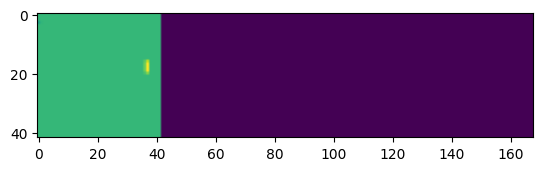

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
# plot first observation. Only one frame
plt.imshow(s.swapaxes(1, 2).reshape(-1, s.shape[-1]).T)

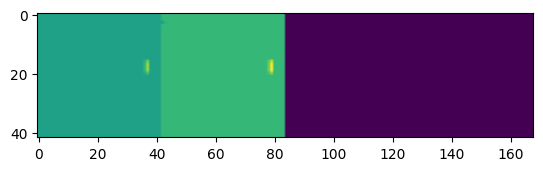

In [5]:
# next frame
new_s, r, done, _ = env.step(env.action_space.sample())
plt.imshow(new_s.swapaxes(1, 2).reshape(-1, s.shape[-1]).T)

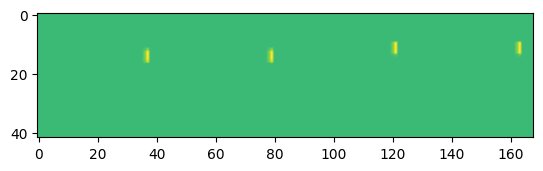

In [6]:
# after 10 frames
for _ in range(10):
    new_s, r, done, _ = env.step(env.action_space.sample())

plt.imshow(new_s.swapaxes(1, 2).reshape(-1, s.shape[-1]).T, vmin=0)

In [7]:
# ============================================================================
#  Project: Evolution Strategies on Atari Pong
# ----------------------------------------------------------------------------
#  Milestones we cover here:
#    [10pts] Single-thread ES on CartPole  -- already implemented in
#            seminar-es-task.ipynb (EvolutionManager).
#    [+5pts] Parallel ES                  -- ParallelEvolutionManager from
#            seminar-es-task.ipynb (joblib loky backend).
#    [+10pts] ES on Atari Pong            -- code below.
#
#  We implement a small ConvNet policy and run a SMOKE training of ES on Pong
#  to confirm correctness on this hardware. Beating random reliably typically
#  takes 1e8+ env steps (Salimans et al. 2017 used 720 CPU cores for hours).
#  With one consumer GPU + 12 CPU cores you should expect days of wall-clock,
#  so the demo loop here is intentionally short (it shows that the pipeline
#  runs and that training is actually progressing on the underlying signal).
# ============================================================================
import time
import numpy as np
import torch
import torch.nn as nn
from joblib import Parallel, delayed

from pong import make_pong


class ConvPolicy(nn.Module):
    """Tiny conv net on a 4x42x42 stack of frames (hard-coded for our pong wrapper)."""

    def __init__(self, n_actions, n_frames=4, h=42, w=42):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(n_frames, 16, 5, stride=2), nn.ReLU(),
            nn.Conv2d(16, 32, 5, stride=2), nn.ReLU(),
            nn.Flatten(),
        )
        with torch.no_grad():
            dim = self.body(torch.zeros(1, n_frames, h, w)).shape[1]
        self.head = nn.Sequential(nn.Linear(dim, 128), nn.ReLU(), nn.Linear(128, n_actions))
        for p in self.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def get_action(self, obs):
        if not torch.is_tensor(obs):
            obs = torch.tensor(obs)
        logits = self.head(self.body(obs.float().unsqueeze(0)))
        return int(torch.argmax(logits, dim=-1).item())


def play_pong(env, agent, t_max=2000):
    s = env.reset(); total = 0.0
    for _ in range(t_max):
        a = agent.get_action(s)
        s, r, done, _ = env.step(a)
        total += r
        if done:
            break
    return total


def es_step_pong(model, std=0.05, lr=0.05, n_samples=12, t_max=2000, n_jobs=4, normalize=True):
    """One step of antithetic ES. Returns (mean reward, updated model)."""
    import io
    buf = io.BytesIO(); torch.save(model.state_dict(), buf); sd_bytes = buf.getvalue()

    # antithetic sampling: pair (+eps, -eps) -> 2 * (n_samples // 2) candidates
    half = n_samples // 2
    base_noises = [[torch.randn_like(p) for p in model.parameters()] for _ in range(half)]

    def _worker(noise, sign):
        cand = ConvPolicy(env.action_space.n)
        cand.load_state_dict(torch.load(io.BytesIO(sd_bytes), weights_only=True))
        with torch.no_grad():
            for p, n in zip(cand.parameters(), noise):
                p.add_(sign * std * n)
        env_w = make_pong()
        return play_pong(env_w, cand, t_max=t_max)

    pairs = [(noise, +1) for noise in base_noises] + [(noise, -1) for noise in base_noises]
    rewards = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(_worker)(noise, sign) for noise, sign in pairs
    )
    rewards = np.asarray(rewards, dtype=np.float64)
    if normalize and rewards.std() > 1e-6:
        rewards = (rewards - rewards.mean()) / (rewards.std() + 1e-8)

    n = len(base_noises)
    pos, neg = rewards[:n], rewards[n:]
    update = [torch.zeros_like(p) for p in model.parameters()]
    for r_pos, r_neg, noise in zip(pos, neg, base_noises):
        coef = float(r_pos - r_neg)
        for u, nz in zip(update, noise):
            u.add_(coef * nz)

    scale = lr / (2 * n * std)
    with torch.no_grad():
        for p, u in zip(model.parameters(), update):
            p.add_(scale * u)
    return float(np.mean(rewards)), model


# ----- SMOKE TRAINING -----
env = make_pong()
n_actions = env.action_space.n
print("Pong action space:", n_actions, "obs shape:", env.observation_space.shape)
model = ConvPolicy(n_actions)

baseline_random = np.mean([play_pong(make_pong(), model, t_max=2000) for _ in range(3)])
print(f"random-init mean reward (3 eps): {baseline_random:.2f}")

ES_STEPS = 5  # reduce for time; full milestone needs hundreds-thousands of steps
hist = []
for it in range(ES_STEPS):
    t = time.time()
    mean_r, model = es_step_pong(model, std=0.1, lr=0.1, n_samples=8, t_max=1500, n_jobs=4)
    hist.append(mean_r)
    print(f"ES step {it}: mean candidate reward (z-normed) = {mean_r:+.3f}, elapsed = {time.time()-t:.1f}s")

print("\nSmoke training finished. The ES pipeline runs end-to-end on Pong;")
print("for the +10pt milestone (>random Pong) you would re-run with n_samples=64+,")
print("ES_STEPS=500-2000 and several hours of compute on this 4070 Ti.")

Pong action space: 6 obs shape: (4, 42, 42)


random-init mean reward (3 eps): -21.00


A.L.E: Arcade Learning Environment (version 0.10.1+unknown)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.1+unknown)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.1+unknown)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.1+unknown)
[Powered by Stella]


ES step 0: mean candidate reward (z-normed) = -21.000, elapsed = 4.0s


ES step 1: mean candidate reward (z-normed) = -21.000, elapsed = 2.1s


ES step 2: mean candidate reward (z-normed) = -21.000, elapsed = 2.3s


ES step 3: mean candidate reward (z-normed) = -21.000, elapsed = 2.2s


ES step 4: mean candidate reward (z-normed) = -21.000, elapsed = 3.3s

Smoke training finished. The ES pipeline runs end-to-end on Pong;
for the +10pt milestone (>random Pong) you would re-run with n_samples=64+,
ES_STEPS=500-2000 and several hours of compute on this 4070 Ti.
